Titanic-datasetet: 

Denna uppgift går ut på att förutsäga vilka passagerare som överlevde Titanic-katastrofen

- träna en modell som förutsäger kolumnen Survived baserat på de andra särdragen


In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_titanic_data():
    tarball_path = Path('datasets/titanic.tgz')
    if not tarball_path.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://github.com/ageron/data/raw/main/titanic.tgz'
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets", filter="data")
    return [pd.read_csv(Path('datasets/titanic') / filename) for filename in ('train.csv', 'test.csv')]

In [ ]:
train_data, test_data = load_titanic_data() # test data is made so that it does not contain the target!

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_data = train_data.set_index('PassengerId')
test_data = test_data.set_index('PassengerId')

## Exploratory Data Analysis

In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [7]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
train_data[train_data['Fare']>250] 

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
743,1,1,"Ryerson, Miss. Susan Parker 'Suzette'",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [11]:
train_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [12]:
train_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [13]:
train_data["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

## Data transformation

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()) 
])

In [15]:
cat_pipeline = Pipeline([
    ('ordinal_encoder', OrdinalEncoder()),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_encoder', OneHotEncoder(sparse_output=False))
])

In [16]:
num_attribs = ['Age', 'SibSp', 'Parch', 'Fare']
cat_attribs = ['Pclass', 'Sex', 'Embarked']

preprocess_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

The pipeline should transform the features (X) not the target (y)

In [17]:
X_train = preprocess_pipeline.fit_transform(train_data)

In [18]:
y_train = train_data['Survived']

The target should just be raw. 0 or 1. The raw truth that the model should learn to predict. It already has the right format.

## Building and training a model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42) #n_parameters: hyperparameter of randomforestclassifier, how many trees that should be built. They will vote?
forest_classifier.fit(X_train, y_train) #supervised training - WITH labels

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Testing the model

In [22]:
X_test = preprocess_pipeline.transform(test_data) # test data does not have target because of Kaggle 

y_pred = forest_classifier.predict(X_test)

y_pred

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

## Evaluating the model

With accuracy-score

In [21]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_classifier, X_train, y_train, cv=10) #10 folds
#model is trained 10 times, each time the 1 fold used for validation changes. we get 10 accuracy-scores
forest_scores.mean() #the mean of the 10 accuracy-scores is a stable estimation of how good the model is. 

np.float64(0.8137578027465668)

This is generally not the prefered performance measure for classifiers, especially for skewed datasets. 
A much better way to evaluate classifiers is to look at the CONFUSION MATRIX. 

Tho, we cannot compute confusion_matrix on the test.csv since it doesnt't have labels. Instead we can compute it on cross-validation predictions (or any data set where you know the true labels)

In [ ]:
from sklearn.model_selection import cross_val_predict 
from sklearn.metrics import confusion_matrix 

y_pred_cv = cross_val_predict(forest_classifier, X_train, y_train, cv=10) # 5 or 10 folds are industry standards, 
                                                                        #5 is still reliable but faster. 10 is good for small datasets like this one tho 
# vector of predictions for every training sample
# y_pred_cv contains "new" predictions of the training data. avoiding data leakage - "out-of-folds-predictions"
# each sample was predicted once, but always by a model that did NOT see that sample during training. 
cm = confusion_matrix(y_train, y_pred_cv) # pass it the target classes and the predicted classes
cm

array([[467,  82],
       [ 91, 251]])

A more concise metric is PRECISION of the classifier. This is the accruacy of the positive predictions.

True Positives / True Positives + False Positives

This is used together with RECALL (sensitivity, True Positive Rate)

True Positive / True Positive + False Negative 

In this case... Survived: 0 or 1. What is Positive? --> Answer: In a binary classification with labels 0 and 1, the positive class is always the class with label 1.

In [31]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train, y_pred_cv)


0.7537537537537538

Our RandomForestRegress-model only gets it right 75 % of the time. 

In [32]:
recall_score(y_train, y_pred_cv)

0.7339181286549707

And it only catches 73% 

F1-score (harmonic mean of precision and recall)- when you need a single metric to compare two classifiers! The harmonic mean gives much more weight to low values. As a result, the classifier will only get a gigh f1 score if both recall and precision are high. Favors classifiers that have similar precision and recall. This is not always what you want, sometimes one is more important.

In [33]:
from sklearn.metrics import f1_score

f1_score(y_train, y_pred_cv)

0.7437037037037038

Instea of calling the classifier's predict() method, you can call its decision_function() method, which returns a score for each instance. You can then use any threshold you want to make predictions based on those scores:

In [36]:
#y_scores = forest_classifier.decision_function([]) # forestclassifier doesnt have decision_function, it has predict_proba

# ROC curve requires scores - for binary classification, the probability of the positive class 
y_scores = forest_classifier.predict_proba(X_train)[:,1]


This gives us a vector of possibilities to give to the ROC curve

For now: let's see if we can do a nice curve. We choose the ROC curve, rather than the PR curve because...

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

# first we use this function to compute the TPR and FPR for various threshholds

#compute ROC curve
fpr, tpr, threshholds = roc_curve(y_train, y_scores)
#compute AUC
auc = roc_auc_score(y_train, y_scores)

auc

0.9972384665367121

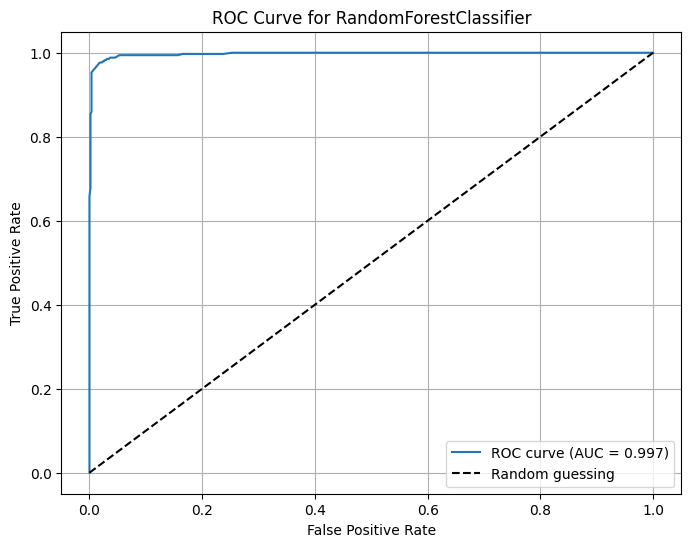

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for RandomForestClassifier")
plt.legend()
plt.grid(True)
plt.show()

What does this mean?? I think it means the model is good because the ROC curve is very close to the corner. Right it says AUC=0.997 and a perfect classifier will have a ROC AUC equal to 1. 

At this point we could try to improve the model. We didn't look for the best hyperparametres for example.  Or better yet try other models and evaluate them. 